# Instalación de dependencias

In [2]:
!pip install git+https://github.com/openai/CLIP.git
!pip install scikit-learn matplotlib pillow numpy

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-49kjp6u1
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-49kjp6u1
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=71331f497be31dec9e71d3f26d3f4c0cef1c4fe13a6edc656992595781bff873
  Stored in directory: /tmp/pip-ephem-wheel-cache-8lgg_cgx/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


# Importaciones

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import clip
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# Configuración y carga del modelo

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

Usando dispositivo: cpu


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 161MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

# Subir imágenes manualmente

In [5]:
from google.colab import files
print("Sube tus imágenes (puedes seleccionar varias):")
uploaded = files.upload()

Sube tus imágenes (puedes seleccionar varias):


Saving imagen1.jpg to imagen1.jpg
Saving imagen2.jpg to imagen2.jpg
Saving imagen3.jpg to imagen3.jpg
Saving imagen4.jpg to imagen4.jpg
Saving imagen5.jpg to imagen5.jpg
Saving imagen6.jpg to imagen6.jpg
Saving imagen7.jpg to imagen7.jpg
Saving imagen8.jpg to imagen8.jpg


In [8]:
import os
# Crear carpeta 'images' si no existe
os.makedirs("images", exist_ok=True)

# Mover todos los archivos .jpg (o imágenes) a la carpeta 'images'
import glob
for f in glob.glob("*.jpg") + glob.glob("*.jpeg") + glob.glob("*.png"):
    os.rename(f, os.path.join("images", f))

print(f"Archivos movidos a la carpeta 'images': {os.listdir('images')}")

Archivos movidos a la carpeta 'images': ['imagen4.jpg', 'imagen6.jpg', 'imagen1.jpg', 'imagen2.jpg', 'imagen5.jpg', 'imagen8.jpg', 'imagen3.jpg', 'imagen7.jpg']


In [11]:
# Definir la carpeta y obtener las rutas completas de las imágenes
image_folder = "images"
image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder)
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]

print(f"Se encontraron {len(image_paths)} imágenes:")
print(image_paths)

Se encontraron 8 imágenes:
['images/imagen4.jpg', 'images/imagen6.jpg', 'images/imagen1.jpg', 'images/imagen2.jpg', 'images/imagen5.jpg', 'images/imagen8.jpg', 'images/imagen3.jpg', 'images/imagen7.jpg']


# Preprocesar y generar embeddings

In [12]:
images_tensors = []
for path in image_paths:
    img = Image.open(path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    images_tensors.append(img_tensor)

embeddings = []
with torch.no_grad():
    for img_tensor in images_tensors:
        emb = model.encode_image(img_tensor)
        embeddings.append(emb.cpu().numpy().flatten())
X = np.array(embeddings)
X_norm = normalize(X)

print(f"Shape de los embeddings: {X.shape}")

Shape de los embeddings: (8, 512)


# Reducción con PCA y t-SNE

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)
print(f"Varianza explicada PCA: {pca.explained_variance_ratio_}")

tsne = TSNE(n_components=2, perplexity=min(30, len(X)-1), random_state=42)
X_tsne = tsne.fit_transform(X_norm)

Varianza explicada PCA: [0.23864433 0.18109015]


# Visualización

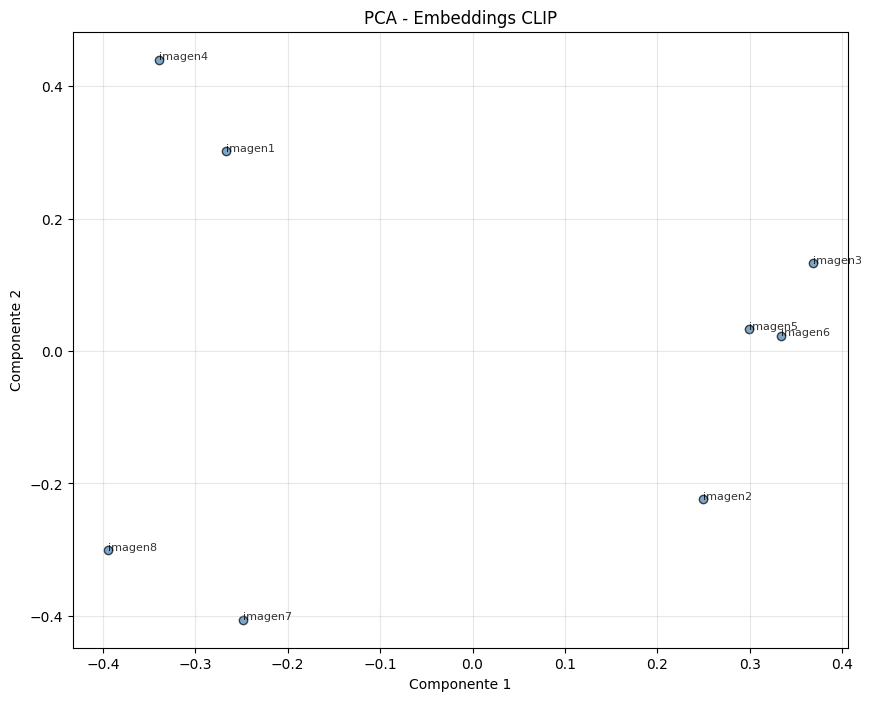

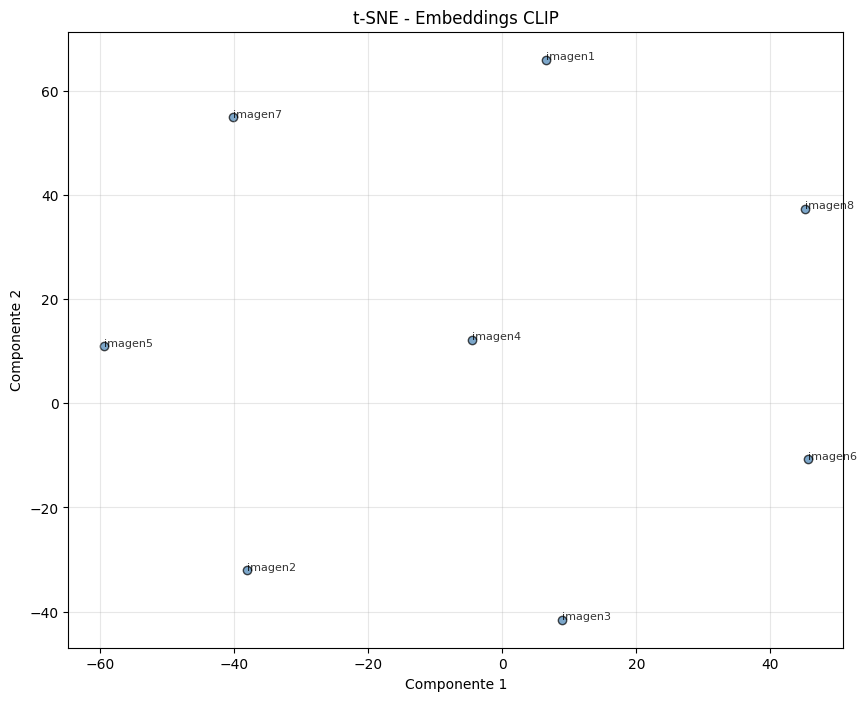

In [14]:
def plot_2d(X_2d, paths, title, save_name=None):
    plt.figure(figsize=(10, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c='steelblue', edgecolors='k', alpha=0.7)
    for i, p in enumerate(paths):
        label = os.path.basename(p).split('.')[0][:10]
        plt.annotate(label, (X_2d[i, 0], X_2d[i, 1]), fontsize=8, alpha=0.8)
    plt.title(title)
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.grid(alpha=0.3)
    if save_name:
        plt.savefig(save_name, dpi=150)
    plt.show()

plot_2d(X_pca, image_paths, "PCA - Embeddings CLIP", "pca_clip.png")
plot_2d(X_tsne, image_paths, "t-SNE - Embeddings CLIP", "tsne_clip.png")

# Clustering con KMeans

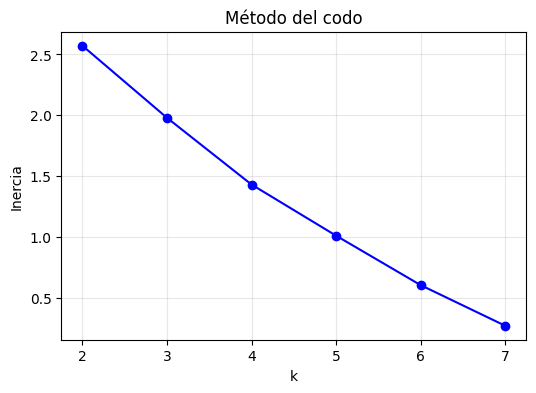

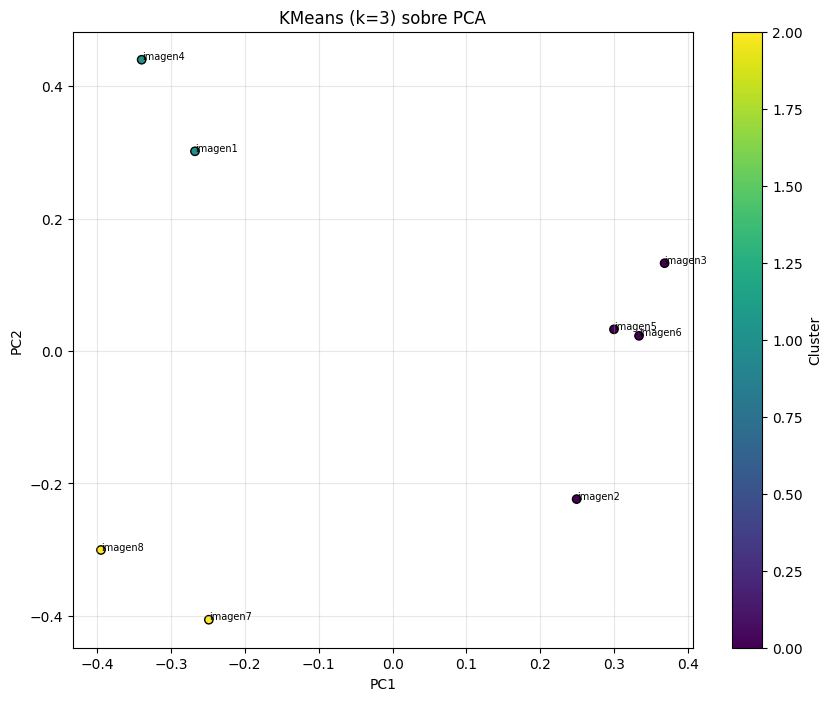

In [21]:
# Método del codo
inertias = []
K_range = range(2, min(10, len(X)))
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_norm)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(alpha=0.3)
plt.savefig("elbow.png")
plt.show()

k = 3  # ajusta según el gráfico
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_norm)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', edgecolors='k')
plt.colorbar(scatter, label="Cluster")
for i, p in enumerate(image_paths):
    plt.annotate(os.path.basename(p).split('.')[0][:8], (X_pca[i,0], X_pca[i,1]), fontsize=7)
plt.title(f"KMeans (k={k}) sobre PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.savefig("kmeans_clusters.png")
plt.show()

#  Proyección de prompts de texto

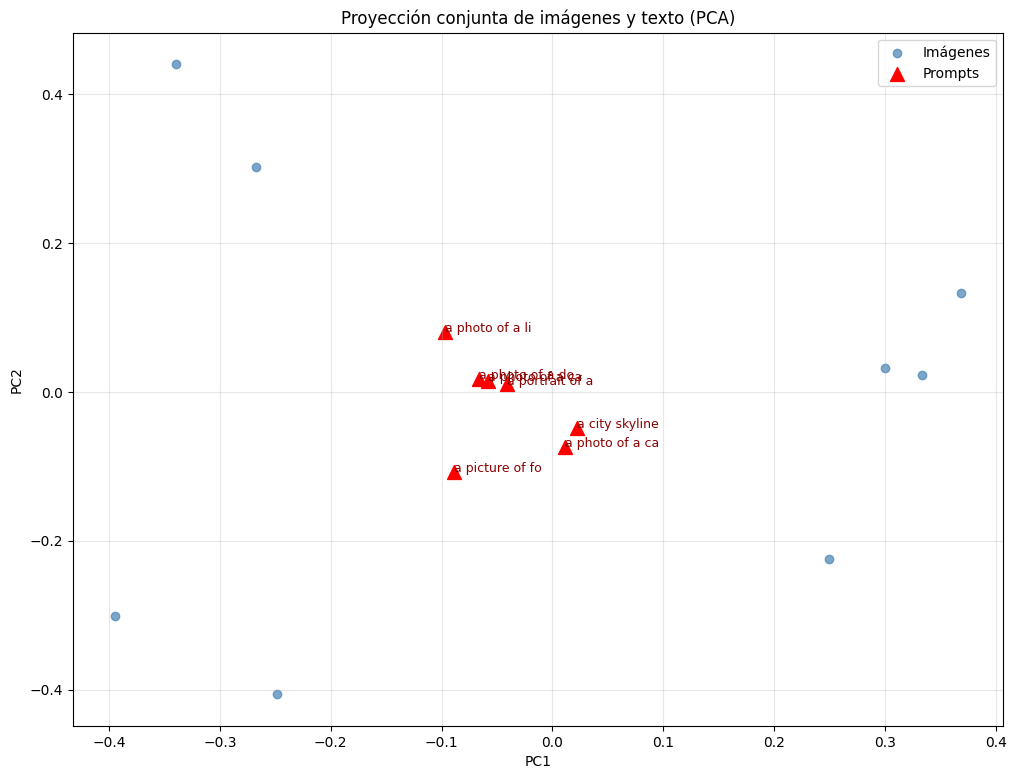

In [24]:
text_prompts = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
    "a city skyline",
    "a portrait of a person",
    "a picture of food",
    "a photo of a lion"
]
text_tokens = clip.tokenize(text_prompts).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features.cpu().numpy()
text_features_norm = normalize(text_features)

text_pca = pca.transform(text_features_norm)

plt.figure(figsize=(12, 9))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue', label='Imágenes', alpha=0.7)
plt.scatter(text_pca[:, 0], text_pca[:, 1], c='red', marker='^', s=100, label='Prompts')
for i, prompt in enumerate(text_prompts):
    plt.annotate(prompt[:15], (text_pca[i, 0], text_pca[i, 1]), fontsize=9, color='darkred')
plt.title("Proyección conjunta de imágenes y texto (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("images_text_pca.png")
plt.show()

In [25]:
# Ejemplo de similitud
example_idx = 0
example_emb = X_norm[example_idx:example_idx+1]
similarities = np.dot(example_emb, text_features_norm.T).flatten()
print("\n--- Similitud imagen - texto ---")
print(f"Imagen: {os.path.basename(image_paths[example_idx])}")
for i, prompt in enumerate(text_prompts):
    print(f"{prompt:25} : {similarities[i]:.4f}")
best = np.argmax(similarities)
print(f"Prompt más similar: '{text_prompts[best]}' (sim = {similarities[best]:.4f})")


--- Similitud imagen - texto ---
Imagen: imagen4.jpg
a photo of a cat          : 0.2328
a photo of a dog          : 0.2128
a photo of a car          : 0.1818
a city skyline            : 0.1474
a portrait of a person    : 0.2160
a picture of food         : 0.1988
a photo of a lion         : 0.3114
Prompt más similar: 'a photo of a lion' (sim = 0.3114)


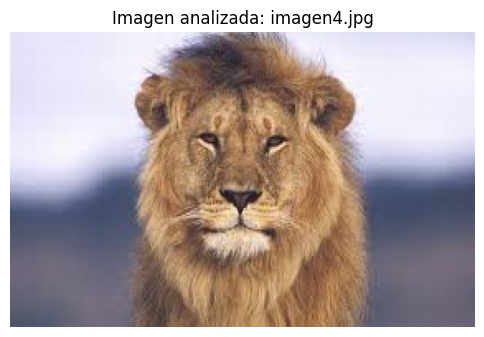

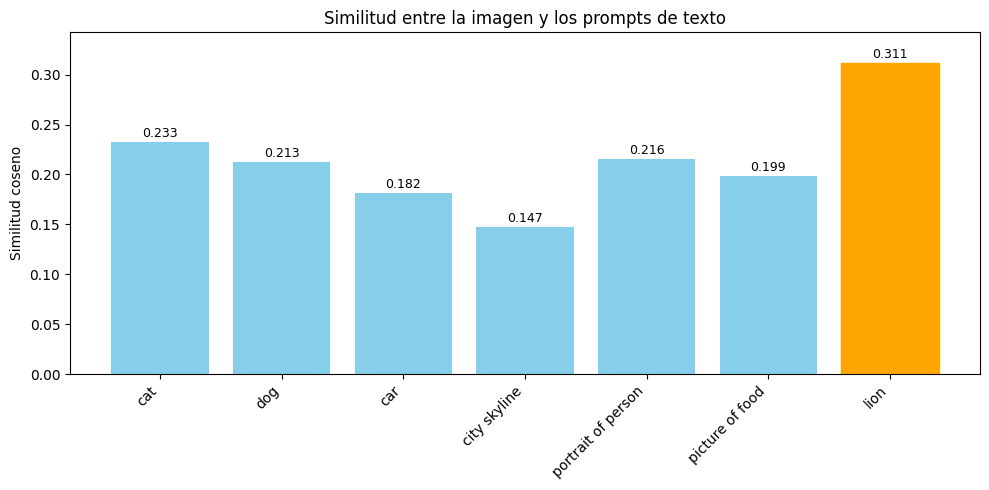

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Mostrar la imagen evaluada
img_display = Image.open(image_paths[example_idx])
plt.figure(figsize=(6,4))
plt.imshow(img_display)
plt.title(f"Imagen analizada: {os.path.basename(image_paths[example_idx])}")
plt.axis('off')
plt.show()

# Calcular el índice de mayor similitud
best_match_idx = np.argmax(similarities)

# Gráfico de barras
plt.figure(figsize=(10,5))
prompts_short = [p.replace("a photo of a ", "").replace("a ", "") for p in text_prompts]
bars = plt.bar(prompts_short, similarities, color='skyblue')
bars[best_match_idx].set_color('orange')
plt.ylabel("Similitud coseno")
plt.title("Similitud entre la imagen y los prompts de texto")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(similarities)*1.1)
for i, v in enumerate(similarities):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()